# Análisis Exploratorio de Datos (EDA)
## Liga de Fútbol - Dataset Sintético

Este notebook contiene un análisis exploratorio detallado del dataset de la liga de fútbol.

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 3)

## 2. Carga de Datos

In [2]:
# Cargar el dataset
data_path = Path('../data/datos_liga_futbol.csv')
df = pd.read_csv(data_path)

print(f"Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

Dataset cargado exitosamente
Dimensiones: 280 filas x 14 columnas


## 3. Inspección Inicial

In [3]:
# Primeras filas del dataset
print("=" * 80)
print("PRIMERAS 10 FILAS DEL DATASET")
print("=" * 80)
df.head(10)

PRIMERAS 10 FILAS DEL DATASET


,Temporada,Jornada,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,Resultado,Ganador,Juega_En_Casa,Probabilidad_Victoria_Local,Habilidad_Local,Habilidad_Visitante,Racha_Local,Racha_Visitante
0,1,1,Tigres FC,Águilas United,4,2,Victoria Local,Tigres FC,True,0.576,85,82,0,0
1,1,1,Tigres FC,Zorros FC,1,3,Victoria Visitante,Zorros FC,True,0.501,85,65,1,0
2,1,1,Lobos Atlético,Zorros FC,2,0,Victoria Local,Lobos Atlético,True,0.704,72,65,0,1
3,1,1,Águilas United,Cóndores United,5,0,Victoria Local,Águilas United,True,0.706,82,60,0,0
4,1,2,Leones SC,Zorros FC,1,2,Victoria Visitante,Zorros FC,True,0.248,78,65,0,0
5,1,2,Cóndores United,Águilas United,1,3,Victoria Visitante,Águilas United,True,0.121,60,82,0,1
6,1,2,Pumas CF,Águilas United,1,2,Victoria Visitante,Águilas United,True,0.220,68,82,0,2
7,1,2,Halcones City,Zorros FC,4,0,Victoria Local,Halcones City,True,0.551,75,65,0,1
8,1,3,Zorros FC,Leones SC,1,4,Victoria Visitante,Leones SC,True,0.361,65,78,0,0
9,1,3,Águilas United,Zorros FC,5,4,Victoria Local,Águilas United,True,0.855,82,65,3,0


In [4]:
# Información general del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
df.info()

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Temporada                    280 non-null    int64  
 1   Jornada                      280 non-null    int64  
 2   Equipo_Local                 280 non-null    object 
 3   Equipo_Visitante             280 non-null    object 
 4   Goles_Local                  280 non-null    int64  
 5   Goles_Visitante              280 non-null    int64  
 6   Resultado                    280 non-null    object 
 7   Ganador                      280 non-null    object 
 8   Juega_En_Casa                280 non-null    bool   
 9   Probabilidad_Victoria_Local  280 non-null    float64
 10  Habilidad_Local              280 non-null    int64  
 11  Habilidad_Visitante          280 non-null    int64  
 12  Racha_Local                  280 non-null    i

In [5]:
# Tipos de datos
print("=" * 80)
print("TIPOS DE DATOS")
print("=" * 80)
print(df.dtypes)

TIPOS DE DATOS
Temporada                        int64
Jornada                          int64
Equipo_Local                    object
Equipo_Visitante                object
Goles_Local                      int64
Goles_Visitante                  int64
Resultado                       object
Ganador                         object
Juega_En_Casa                     bool
Probabilidad_Victoria_Local    float64
Habilidad_Local                  int64
Habilidad_Visitante              int64
Racha_Local                      int64
Racha_Visitante                  int64
dtype: object


## 4. Calidad de Datos

In [6]:
# Valores nulos
print("=" * 80)
print("VALORES NULOS")
print("=" * 80)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Valores_Nulos': missing,
    'Porcentaje': missing_pct
})
print(missing_df[missing_df['Valores_Nulos'] > 0])

if missing.sum() == 0:
    print("\n✓ No hay valores nulos en el dataset")

VALORES NULOS
Empty DataFrame
Columns: [Valores_Nulos, Porcentaje]
Index: []

✓ No hay valores nulos en el dataset


In [7]:
# Duplicados
print("=" * 80)
print("VALORES DUPLICADOS")
print("=" * 80)

duplicates = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicates}")

if duplicates == 0:
    print("✓ No hay filas duplicadas en el dataset")

VALORES DUPLICADOS
Número de filas duplicadas: 0
✓ No hay filas duplicadas en el dataset


## 5. Estadísticas Descriptivas

In [8]:
# Estadísticas de variables numéricas
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)
df.describe()

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,Temporada,Jornada,Goles_Local,Goles_Visitante,Probabilidad_Victoria_Local,Habilidad_Local,Habilidad_Visitante,Racha_Local,Racha_Visitante
count,280.000,280.000,280.000,280.000,280.000,280.000,280.000,280.000,280.000
mean,3.000,7.500,2.232,2.121,0.531,73.125,73.125,0.579,0.629
std,1.417,4.038,1.457,1.437,0.218,8.021,8.021,0.955,0.953
min,1.000,1.000,0.000,0.000,0.050,60.000,60.000,0.000,0.000
25%,2.000,4.000,1.000,1.000,0.371,67.250,67.250,0.000,0.000
50%,3.000,7.500,2.000,2.000,0.546,73.500,73.500,0.000,0.000
75%,4.000,11.000,3.000,3.000,0.688,79.000,79.000,1.000,1.000
max,5.000,14.000,9.000,7.000,0.950,85.000,85.000,5.000,5.000


In [9]:
# Estadísticas de variables categóricas
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS")
print("=" * 80)
df.describe(include=['object'])

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS


,Equipo_Local,Equipo_Visitante,Resultado,Ganador
count,280,280,280,280
unique,8,8,3,9
top,Tigres FC,Águilas United,Victoria Local,Empate
freq,35,35,121,54


## 6. Análisis por Temporada

In [10]:
# Partidos por temporada
print("=" * 80)
print("DISTRIBUCIÓN DE PARTIDOS POR TEMPORADA")
print("=" * 80)

temporadas = df['Temporada'].value_counts().sort_index()
print(temporadas)
print(f"\nTotal de temporadas: {df['Temporada'].nunique()}")
print(f"Total de jornadas por temporada: {df.groupby('Temporada')['Jornada'].max().values}")

DISTRIBUCIÓN DE PARTIDOS POR TEMPORADA
Temporada
1    56
2    56
3    56
4    56
5    56
Name: count, dtype: int64

Total de temporadas: 5
Total de jornadas por temporada: [14 14 14 14 14]


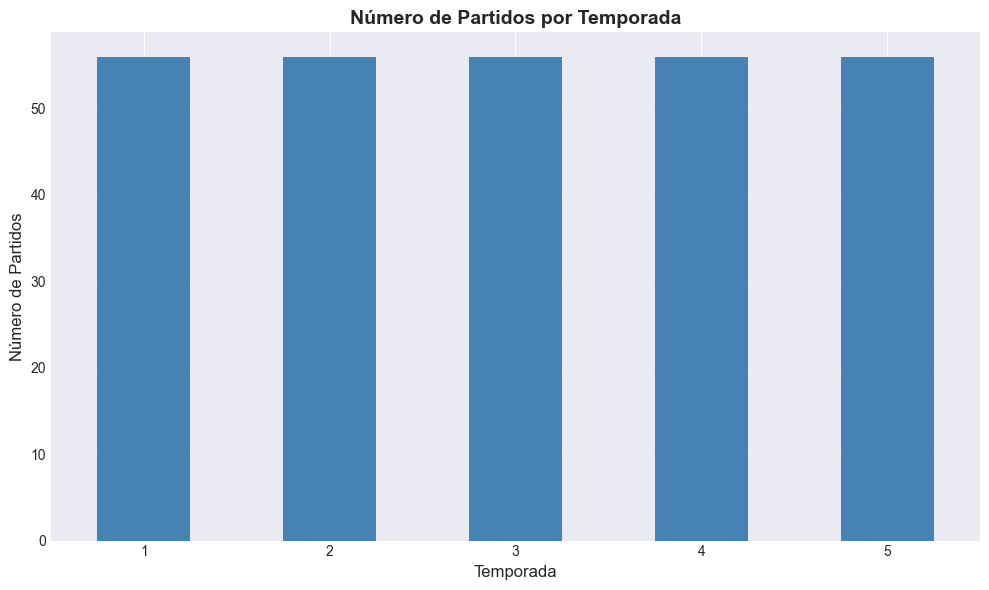

In [11]:
# Visualización de partidos por temporada
fig, ax = plt.subplots(figsize=(10, 6))
temporadas.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Número de Partidos por Temporada', fontsize=14, fontweight='bold')
ax.set_xlabel('Temporada', fontsize=12)
ax.set_ylabel('Número de Partidos', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Análisis de Equipos

In [12]:
# Equipos únicos
print("=" * 80)
print("EQUIPOS EN LA LIGA")
print("=" * 80)

equipos_local = set(df['Equipo_Local'].unique())
equipos_visitante = set(df['Equipo_Visitante'].unique())
equipos_todos = sorted(equipos_local.union(equipos_visitante))

print(f"Número de equipos: {len(equipos_todos)}")
print(f"\nEquipos: {', '.join(equipos_todos)}")

EQUIPOS EN LA LIGA
Número de equipos: 8

Equipos: Cóndores United, Halcones City, Leones SC, Lobos Atlético, Pumas CF, Tigres FC, Zorros FC, Águilas United


In [13]:
# Participación de equipos
partidos_local = df['Equipo_Local'].value_counts()
partidos_visitante = df['Equipo_Visitante'].value_counts()
partidos_totales = (partidos_local + partidos_visitante).sort_values(ascending=False)

print("=" * 80)
print("PARTIDOS JUGADOS POR EQUIPO")
print("=" * 80)
print(partidos_totales)

PARTIDOS JUGADOS POR EQUIPO
Cóndores United    70
Halcones City      70
Leones SC          70
Lobos Atlético     70
Pumas CF           70
Tigres FC          70
Zorros FC          70
Águilas United     70
Name: count, dtype: int64


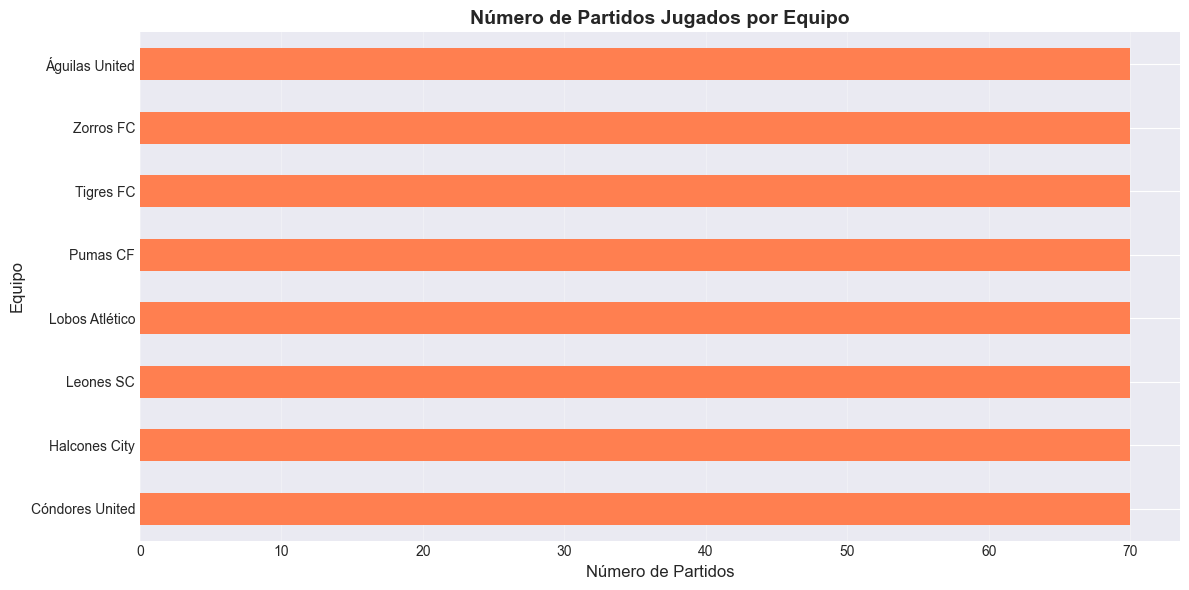

In [14]:
# Visualización de participación de equipos
fig, ax = plt.subplots(figsize=(12, 6))
partidos_totales.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Número de Partidos Jugados por Equipo', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Partidos', fontsize=12)
ax.set_ylabel('Equipo', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Análisis de Resultados

In [15]:
# Distribución de resultados
print("=" * 80)
print("DISTRIBUCIÓN DE RESULTADOS")
print("=" * 80)

resultados = df['Resultado'].value_counts()
resultados_pct = (resultados / len(df) * 100).round(2)

resultado_df = pd.DataFrame({
    'Cantidad': resultados,
    'Porcentaje': resultados_pct
})
print(resultado_df)

DISTRIBUCIÓN DE RESULTADOS
                    Cantidad  Porcentaje
Resultado                               
Victoria Local           121       43.21
Victoria Visitante       105       37.50
Empate                    54       19.29


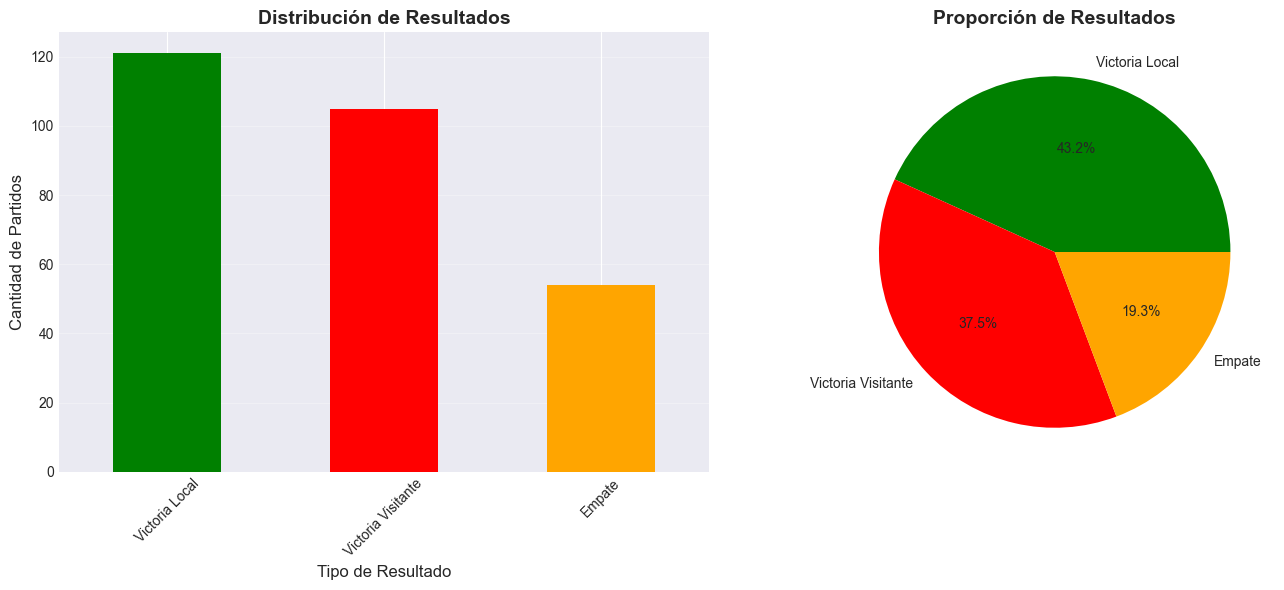

In [16]:
# Visualización de resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras
resultados.plot(kind='bar', ax=ax1, color=['green', 'red', 'orange'])
ax1.set_title('Distribución de Resultados', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tipo de Resultado', fontsize=12)
ax1.set_ylabel('Cantidad de Partidos', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Gráfico de pastel
resultados.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=['green', 'red', 'orange'])
ax2.set_title('Proporción de Resultados', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

In [17]:
# Ventaja de jugar en casa
print("=" * 80)
print("VENTAJA DE JUGAR EN CASA")
print("=" * 80)

victorias_local = len(df[df['Resultado'] == 'Victoria Local'])
victorias_visitante = len(df[df['Resultado'] == 'Victoria Visitante'])
empates = len(df[df['Resultado'] == 'Empate'])

total_partidos = len(df)
print(f"Victorias Local: {victorias_local} ({victorias_local/total_partidos*100:.2f}%)")
print(f"Victorias Visitante: {victorias_visitante} ({victorias_visitante/total_partidos*100:.2f}%)")
print(f"Empates: {empates} ({empates/total_partidos*100:.2f}%)")
print(f"\nVentaja Local: {(victorias_local - victorias_visitante)/total_partidos*100:.2f} puntos porcentuales")

VENTAJA DE JUGAR EN CASA
Victorias Local: 121 (43.21%)
Victorias Visitante: 105 (37.50%)
Empates: 54 (19.29%)

Ventaja Local: 5.71 puntos porcentuales


## 9. Análisis de Goles

In [18]:
# Estadísticas de goles
print("=" * 80)
print("ESTADÍSTICAS DE GOLES")
print("=" * 80)

print("\nGoles Local:")
print(df['Goles_Local'].describe())

print("\nGoles Visitante:")
print(df['Goles_Visitante'].describe())

# Total de goles por partido
df['Goles_Total'] = df['Goles_Local'] + df['Goles_Visitante']
print("\nGoles Totales por Partido:")
print(df['Goles_Total'].describe())

ESTADÍSTICAS DE GOLES

Goles Local:
count    280.000
mean       2.232
std        1.457
min        0.000
25%        1.000
50%        2.000
75%        3.000
max        9.000
Name: Goles_Local, dtype: float64

Goles Visitante:
count    280.000
mean       2.121
std        1.437
min        0.000
25%        1.000
50%        2.000
75%        3.000
max        7.000
Name: Goles_Visitante, dtype: float64

Goles Totales por Partido:
count    280.000
mean       4.354
std        2.371
min        0.000
25%        3.000
50%        4.000
75%        5.250
max       16.000
Name: Goles_Total, dtype: float64


C:\Users\julih\AppData\Local\Temp\ipykernel_2460\417445645.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df['Goles_Local'], df['Goles_Visitante']],


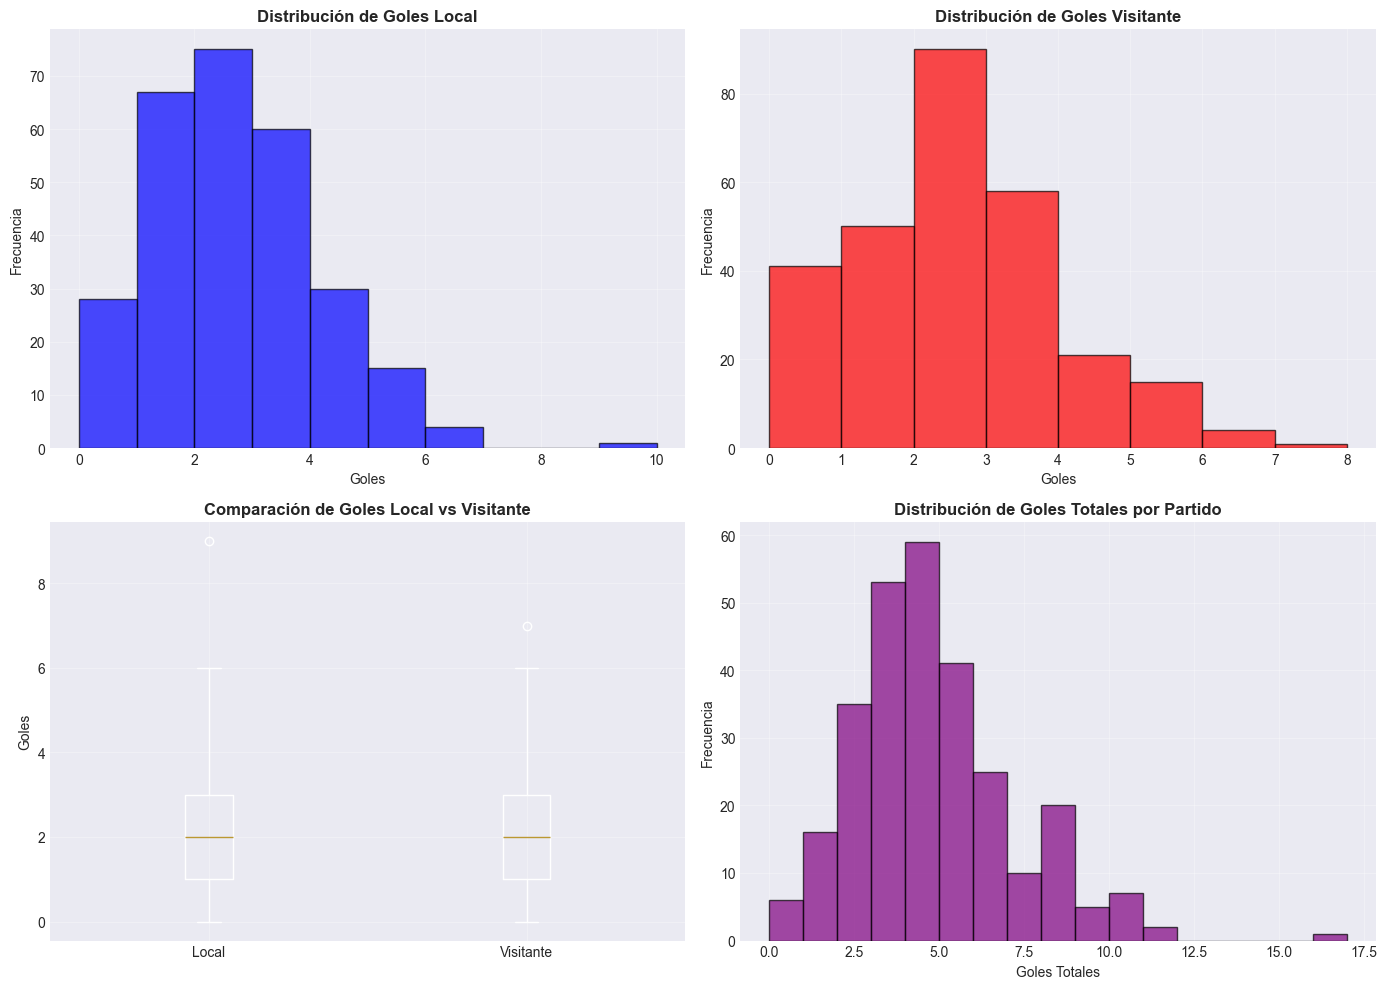

In [19]:
# Visualización de distribución de goles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma goles local
axes[0, 0].hist(df['Goles_Local'], bins=range(0, df['Goles_Local'].max()+2), 
                color='blue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribución de Goles Local', fontweight='bold')
axes[0, 0].set_xlabel('Goles')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(alpha=0.3)

# Histograma goles visitante
axes[0, 1].hist(df['Goles_Visitante'], bins=range(0, df['Goles_Visitante'].max()+2),
                color='red', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribución de Goles Visitante', fontweight='bold')
axes[0, 1].set_xlabel('Goles')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(alpha=0.3)

# Boxplot comparativo
axes[1, 0].boxplot([df['Goles_Local'], df['Goles_Visitante']], 
                    labels=['Local', 'Visitante'])
axes[1, 0].set_title('Comparación de Goles Local vs Visitante', fontweight='bold')
axes[1, 0].set_ylabel('Goles')
axes[1, 0].grid(alpha=0.3)

# Histograma goles totales
axes[1, 1].hist(df['Goles_Total'], bins=range(0, df['Goles_Total'].max()+2),
                color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Distribución de Goles Totales por Partido', fontweight='bold')
axes[1, 1].set_xlabel('Goles Totales')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Partidos de alta y baja anotación
print("=" * 80)
print("PARTIDOS DESTACADOS")
print("=" * 80)

print("\nPartidos con más goles (Top 5):")
print(df.nlargest(5, 'Goles_Total')[['Temporada', 'Jornada', 'Equipo_Local', 'Equipo_Visitante', 
                                       'Goles_Local', 'Goles_Visitante', 'Goles_Total']])

print("\nPartidos sin goles:")
sin_goles = df[df['Goles_Total'] == 0]
print(f"Total: {len(sin_goles)} partidos")
if len(sin_goles) > 0:
    print(sin_goles[['Temporada', 'Jornada', 'Equipo_Local', 'Equipo_Visitante']])

PARTIDOS DESTACADOS

Partidos con más goles (Top 5):
     Temporada  Jornada    Equipo_Local Equipo_Visitante  Goles_Local  \
62           2        2  Lobos Atlético         Pumas CF            9   
66           2        3  Águilas United   Lobos Atlético            5   
271          5       12       Tigres FC    Halcones City            6   
47           1       12       Leones SC         Pumas CF            6   
51           1       13       Zorros FC        Tigres FC            6   

     Goles_Visitante  Goles_Total  
62                 7           16  
66                 6           11  
271                5           11  
47                 4           10  
51                 4           10  

Partidos sin goles:
Total: 6 partidos
     Temporada  Jornada    Equipo_Local Equipo_Visitante
103          2       12       Tigres FC   Lobos Atlético
129          3        5  Águilas United        Leones SC
158          3       12  Lobos Atlético        Leones SC
171          4        1  

## 10. Análisis de Habilidades

In [21]:
# Estadísticas de habilidades
print("=" * 80)
print("ESTADÍSTICAS DE HABILIDADES")
print("=" * 80)

print("\nHabilidad Local:")
print(df['Habilidad_Local'].describe())

print("\nHabilidad Visitante:")
print(df['Habilidad_Visitante'].describe())

# Diferencia de habilidades
df['Diferencia_Habilidad'] = df['Habilidad_Local'] - df['Habilidad_Visitante']
print("\nDiferencia de Habilidad (Local - Visitante):")
print(df['Diferencia_Habilidad'].describe())

ESTADÍSTICAS DE HABILIDADES

Habilidad Local:
count    280.000
mean      73.125
std        8.021
min       60.000
25%       67.250
50%       73.500
75%       79.000
max       85.000
Name: Habilidad_Local, dtype: float64

Habilidad Visitante:
count    280.000
mean      73.125
std        8.021
min       60.000
25%       67.250
50%       73.500
75%       79.000
max       85.000
Name: Habilidad_Visitante, dtype: float64

Diferencia de Habilidad (Local - Visitante):
count    280.000
mean       0.000
std       12.127
min      -25.000
25%      -10.000
50%        0.000
75%       10.000
max       25.000
Name: Diferencia_Habilidad, dtype: float64


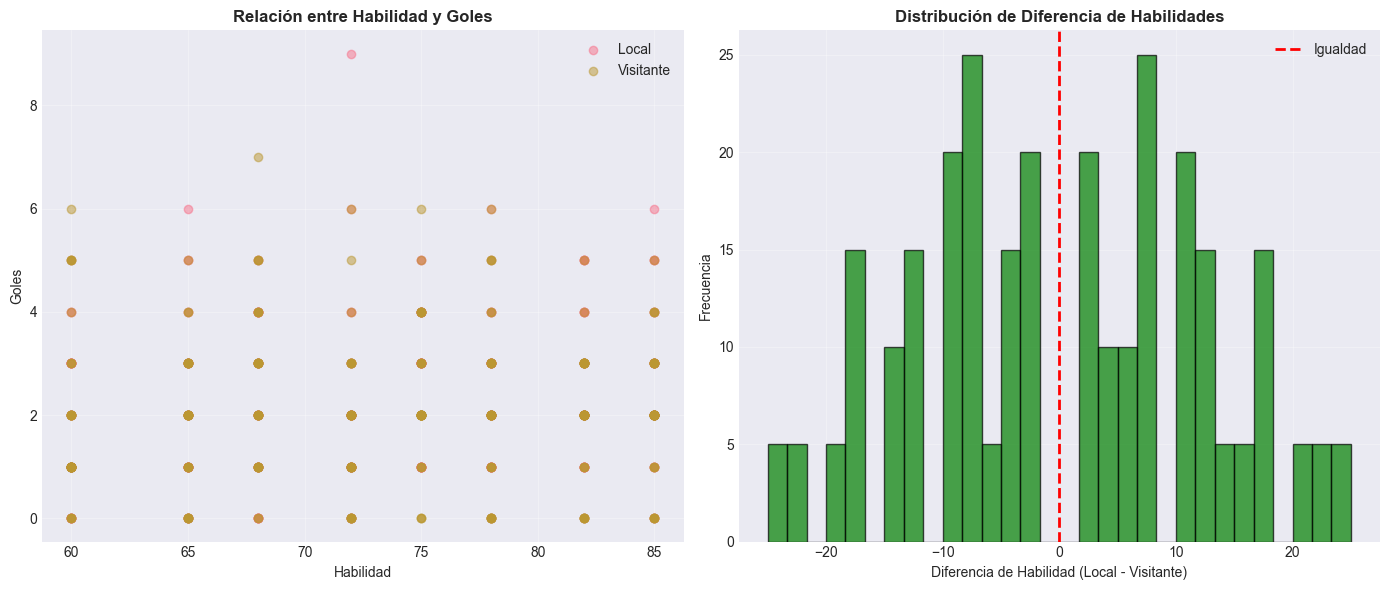

In [22]:
# Visualización de habilidades
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot habilidad vs goles
axes[0].scatter(df['Habilidad_Local'], df['Goles_Local'], alpha=0.5, label='Local')
axes[0].scatter(df['Habilidad_Visitante'], df['Goles_Visitante'], alpha=0.5, label='Visitante')
axes[0].set_title('Relación entre Habilidad y Goles', fontweight='bold')
axes[0].set_xlabel('Habilidad')
axes[0].set_ylabel('Goles')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribución de diferencia de habilidades
axes[1].hist(df['Diferencia_Habilidad'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Igualdad')
axes[1].set_title('Distribución de Diferencia de Habilidades', fontweight='bold')
axes[1].set_xlabel('Diferencia de Habilidad (Local - Visitante)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Análisis de Rachas

In [23]:
# Estadísticas de rachas
print("=" * 80)
print("ESTADÍSTICAS DE RACHAS")
print("=" * 80)

print("\nRacha Local:")
print(df['Racha_Local'].describe())

print("\nRacha Visitante:")
print(df['Racha_Visitante'].describe())

print(f"\nRacha máxima alcanzada (Local): {df['Racha_Local'].max()}")
print(f"Racha máxima alcanzada (Visitante): {df['Racha_Visitante'].max()}")

ESTADÍSTICAS DE RACHAS

Racha Local:
count    280.000
mean       0.579
std        0.955
min        0.000
25%        0.000
50%        0.000
75%        1.000
max        5.000
Name: Racha_Local, dtype: float64

Racha Visitante:
count    280.000
mean       0.629
std        0.953
min        0.000
25%        0.000
50%        0.000
75%        1.000
max        5.000
Name: Racha_Visitante, dtype: float64

Racha máxima alcanzada (Local): 5
Racha máxima alcanzada (Visitante): 5


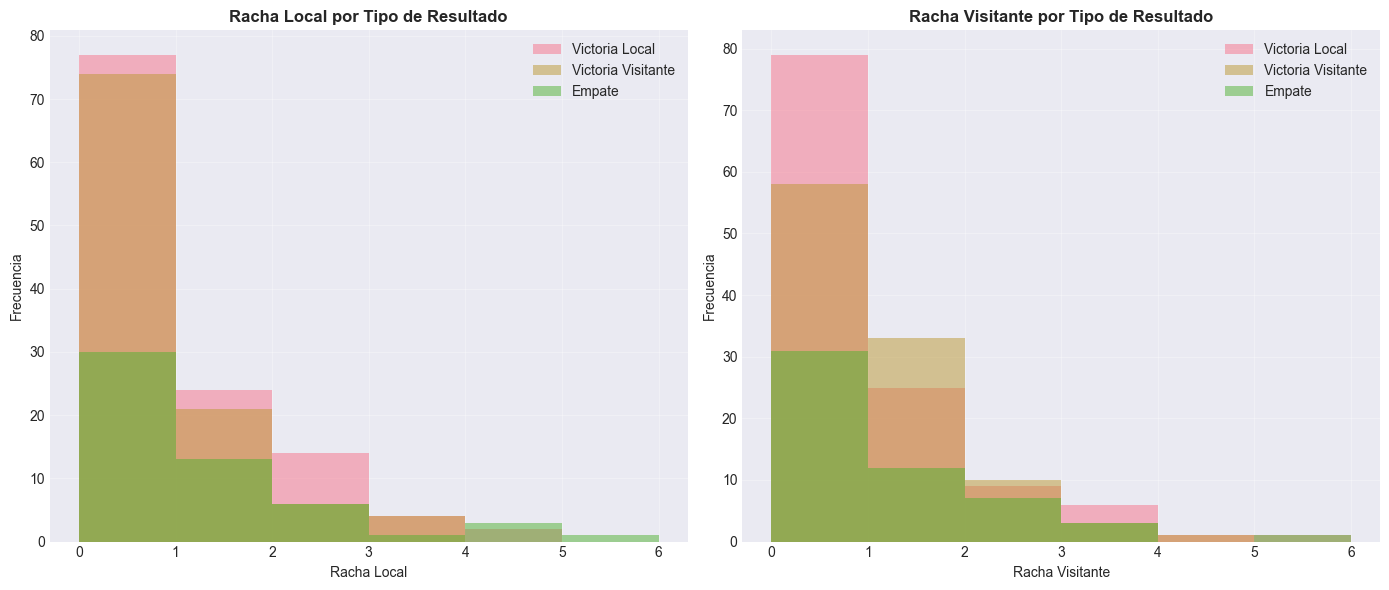

In [24]:
# Impacto de rachas en resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Racha local por resultado
for resultado in df['Resultado'].unique():
    data = df[df['Resultado'] == resultado]['Racha_Local']
    axes[0].hist(data, bins=range(0, int(df['Racha_Local'].max())+2), 
                 alpha=0.5, label=resultado)
axes[0].set_title('Racha Local por Tipo de Resultado', fontweight='bold')
axes[0].set_xlabel('Racha Local')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Racha visitante por resultado
for resultado in df['Resultado'].unique():
    data = df[df['Resultado'] == resultado]['Racha_Visitante']
    axes[1].hist(data, bins=range(0, int(df['Racha_Visitante'].max())+2),
                 alpha=0.5, label=resultado)
axes[1].set_title('Racha Visitante por Tipo de Resultado', fontweight='bold')
axes[1].set_xlabel('Racha Visitante')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Probabilidades de Victoria

In [25]:
# Análisis de probabilidades
print("=" * 80)
print("ANÁLISIS DE PROBABILIDADES DE VICTORIA LOCAL")
print("=" * 80)

print("\nEstadísticas de Probabilidad:")
print(df['Probabilidad_Victoria_Local'].describe())

# Calibración: probabilidad predicha vs resultado real
df['Victoria_Local_Real'] = (df['Resultado'] == 'Victoria Local').astype(int)

# Binning de probabilidades
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
df['Prob_Bin'] = pd.cut(df['Probabilidad_Victoria_Local'], bins=bins, labels=labels)

calibracion = df.groupby('Prob_Bin').agg({
    'Probabilidad_Victoria_Local': 'mean',
    'Victoria_Local_Real': 'mean',
    'Resultado': 'count'
}).round(3)
calibracion.columns = ['Prob_Predicha_Promedio', 'Tasa_Victoria_Real', 'Num_Partidos']

print("\nCalibración de Probabilidades:")
print(calibracion)

ANÁLISIS DE PROBABILIDADES DE VICTORIA LOCAL

Estadísticas de Probabilidad:
count    280.000
mean       0.531
std        0.218
min        0.050
25%        0.371
50%        0.546
75%        0.688
max        0.950
Name: Probabilidad_Victoria_Local, dtype: float64

Calibración de Probabilidades:
          Prob_Predicha_Promedio  Tasa_Victoria_Real  Num_Partidos
Prob_Bin                                                          
0-20%                      0.115               0.105            19
20-40%                     0.310               0.213            61
40-60%                     0.508               0.407            91
60-80%                     0.684               0.623            77
80-100%                    0.899               0.656            32


C:\Users\julih\AppData\Local\Temp\ipykernel_2460\3104135999.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibracion = df.groupby('Prob_Bin').agg({


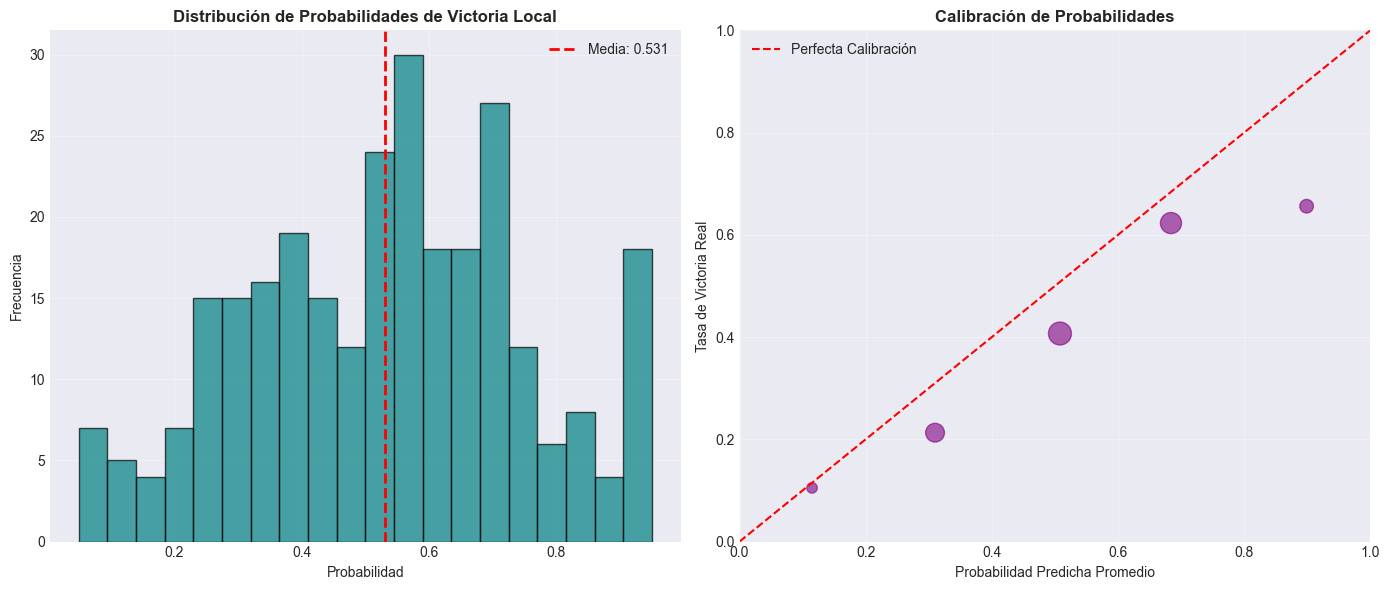

In [26]:
# Visualización de calibración
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribución de probabilidades
axes[0].hist(df['Probabilidad_Victoria_Local'], bins=20, color='teal', 
             alpha=0.7, edgecolor='black')
axes[0].axvline(df['Probabilidad_Victoria_Local'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f"Media: {df['Probabilidad_Victoria_Local'].mean():.3f}")
axes[0].set_title('Distribución de Probabilidades de Victoria Local', fontweight='bold')
axes[0].set_xlabel('Probabilidad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico de calibración
x = calibracion['Prob_Predicha_Promedio'].values
y = calibracion['Tasa_Victoria_Real'].values
axes[1].scatter(x, y, s=calibracion['Num_Partidos']*3, alpha=0.6, color='purple')
axes[1].plot([0, 1], [0, 1], 'r--', label='Perfecta Calibración')
axes[1].set_title('Calibración de Probabilidades', fontweight='bold')
axes[1].set_xlabel('Probabilidad Predicha Promedio')
axes[1].set_ylabel('Tasa de Victoria Real')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 13. Matriz de Correlación

In [27]:
# Seleccionar variables numéricas para correlación
vars_numericas = ['Goles_Local', 'Goles_Visitante', 'Probabilidad_Victoria_Local',
                  'Habilidad_Local', 'Habilidad_Visitante', 'Racha_Local', 'Racha_Visitante']

correlacion = df[vars_numericas].corr()

print("=" * 80)
print("MATRIZ DE CORRELACIÓN")
print("=" * 80)
print(correlacion.round(3))

MATRIZ DE CORRELACIÓN
                             Goles_Local  Goles_Visitante  \
Goles_Local                        1.000            0.343   
Goles_Visitante                    0.343            1.000   
Probabilidad_Victoria_Local        0.230           -0.257   
Habilidad_Local                    0.148           -0.115   
Habilidad_Visitante               -0.074            0.023   
Racha_Local                       -0.014           -0.080   
Racha_Visitante                   -0.007            0.049   

                             Probabilidad_Victoria_Local  Habilidad_Local  \
Goles_Local                                        0.230            0.148   
Goles_Visitante                                   -0.257           -0.115   
Probabilidad_Victoria_Local                        1.000            0.323   
Habilidad_Local                                    0.323            1.000   
Habilidad_Visitante                               -0.207           -0.143   
Racha_Local                

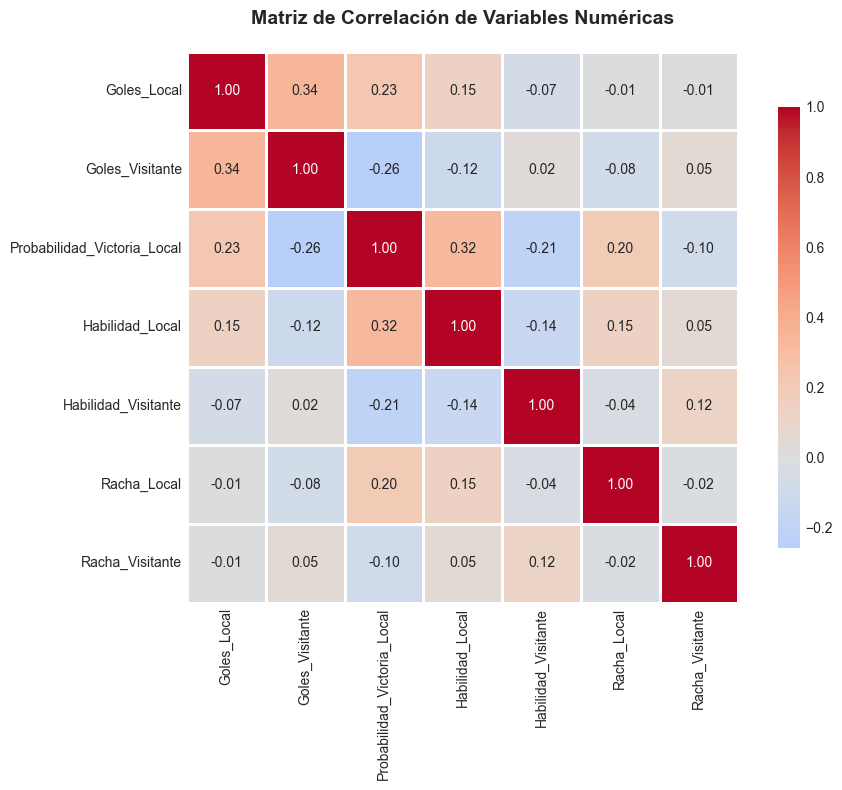

In [28]:
# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 14. Análisis de Rendimiento por Equipo

In [29]:
# Calcular estadísticas por equipo
def calcular_stats_equipo(df, equipos):
    stats = []
    
    for equipo in equipos:
        # Partidos como local
        local = df[df['Equipo_Local'] == equipo]
        # Partidos como visitante
        visitante = df[df['Equipo_Visitante'] == equipo]
        
        # Total de partidos
        total_partidos = len(local) + len(visitante)
        
        # Victorias
        victorias = len(local[local['Resultado'] == 'Victoria Local']) + \
                   len(visitante[visitante['Resultado'] == 'Victoria Visitante'])
        
        # Empates
        empates = len(local[local['Resultado'] == 'Empate']) + \
                 len(visitante[visitante['Resultado'] == 'Empate'])
        
        # Derrotas
        derrotas = total_partidos - victorias - empates
        
        # Goles
        goles_favor = local['Goles_Local'].sum() + visitante['Goles_Visitante'].sum()
        goles_contra = local['Goles_Visitante'].sum() + visitante['Goles_Local'].sum()
        diferencia_goles = goles_favor - goles_contra
        
        # Puntos (3 por victoria, 1 por empate)
        puntos = victorias * 3 + empates
        
        stats.append({
            'Equipo': equipo,
            'Partidos': total_partidos,
            'Victorias': victorias,
            'Empates': empates,
            'Derrotas': derrotas,
            'GF': goles_favor,
            'GC': goles_contra,
            'Dif': diferencia_goles,
            'Puntos': puntos
        })
    
    return pd.DataFrame(stats).sort_values('Puntos', ascending=False)

tabla_general = calcular_stats_equipo(df, equipos_todos)

print("=" * 80)
print("TABLA GENERAL ACUMULADA")
print("=" * 80)
print(tabla_general.to_string(index=False))

TABLA GENERAL ACUMULADA
         Equipo  Partidos  Victorias  Empates  Derrotas  GF  GC  Dif  Puntos
  Halcones City        70         38       14        18 181 135   46     128
      Leones SC        70         33       13        24 155 135   20     112
      Tigres FC        70         32       13        25 161 144   17     109
 Águilas United        70         28       16        26 156 151    5     100
       Pumas CF        70         27       13        30 164 173   -9      94
 Lobos Atlético        70         25       14        31 133 150  -17      89
      Zorros FC        70         24        9        37 137 165  -28      81
Cóndores United        70         19       16        35 132 166  -34      73


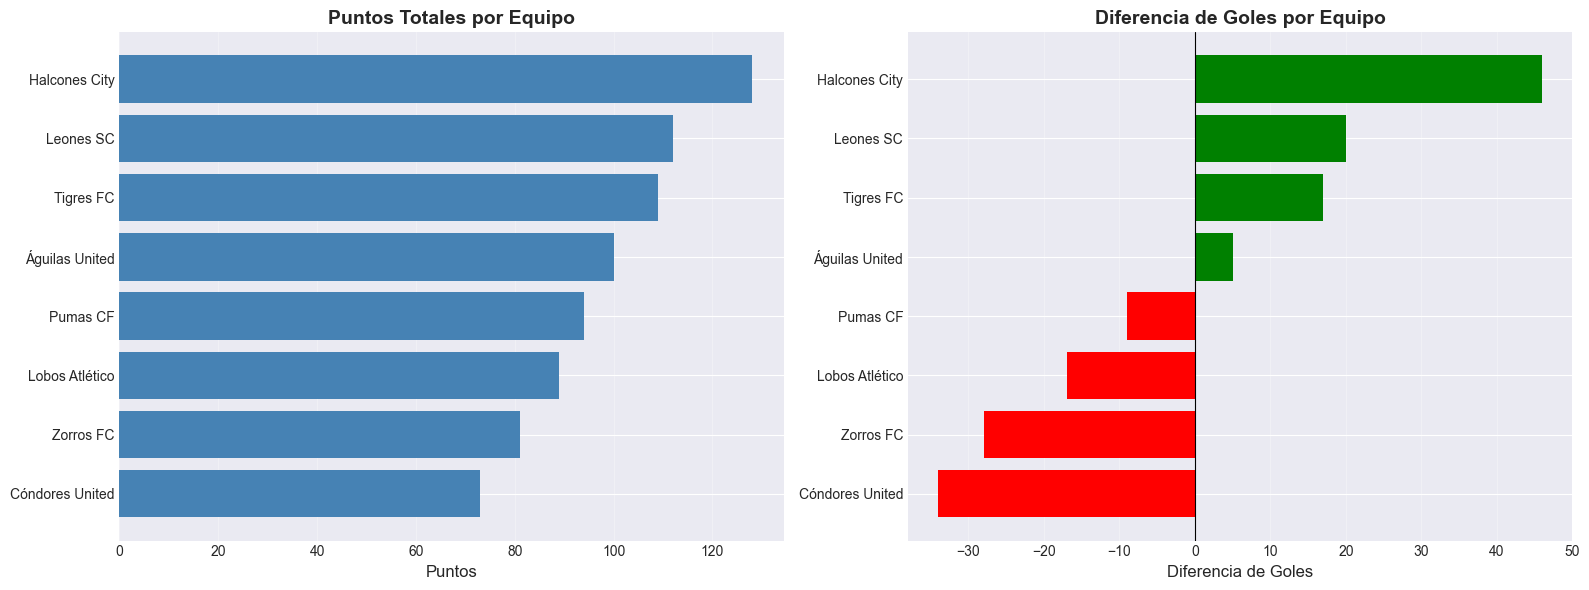

In [30]:
# Visualización de tabla general
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Puntos por equipo
axes[0].barh(tabla_general['Equipo'], tabla_general['Puntos'], color='steelblue')
axes[0].set_title('Puntos Totales por Equipo', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Puntos', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Diferencia de goles
colores = ['green' if x >= 0 else 'red' for x in tabla_general['Dif']]
axes[1].barh(tabla_general['Equipo'], tabla_general['Dif'], color=colores)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Diferencia de Goles por Equipo', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Diferencia de Goles', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Resumen de Hallazgos

In [31]:
print("="*80)
print("RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO")
print("="*80)

print(f"\n1. DIMENSIONES DEL DATASET")
print(f"   - Total de partidos: {len(df)}")
print(f"   - Temporadas analizadas: {df['Temporada'].nunique()}")
print(f"   - Equipos participantes: {len(equipos_todos)}")
print(f"   - Jornadas por temporada: ~{df.groupby('Temporada')['Jornada'].max().mean():.0f}")

print(f"\n2. CALIDAD DE DATOS")
print(f"   - Valores nulos: {df.isnull().sum().sum()}")
print(f"   - Registros duplicados: {df.duplicated().sum()}")
print(f"   - Integridad: ✓ Dataset limpio")

print(f"\n3. RESULTADOS")
print(f"   - Victorias Local: {victorias_local} ({victorias_local/total_partidos*100:.1f}%)")
print(f"   - Victorias Visitante: {victorias_visitante} ({victorias_visitante/total_partidos*100:.1f}%)")
print(f"   - Empates: {empates} ({empates/total_partidos*100:.1f}%)")
print(f"   - Ventaja local: {(victorias_local - victorias_visitante)/total_partidos*100:.1f} p.p.")

print(f"\n4. GOLES")
print(f"   - Promedio goles por partido: {df['Goles_Total'].mean():.2f}")
print(f"   - Promedio goles local: {df['Goles_Local'].mean():.2f}")
print(f"   - Promedio goles visitante: {df['Goles_Visitante'].mean():.2f}")
print(f"   - Partido con más goles: {df['Goles_Total'].max()} goles")
print(f"   - Partidos sin goles: {len(df[df['Goles_Total'] == 0])}")

print(f"\n5. HABILIDADES")
print(f"   - Rango habilidad: {df['Habilidad_Local'].min():.0f} - {df['Habilidad_Local'].max():.0f}")
print(f"   - Diferencia promedio: {df['Diferencia_Habilidad'].mean():.2f}")

print(f"\n6. EQUIPOS DESTACADOS")
print(f"   - Líder en puntos: {tabla_general.iloc[0]['Equipo']} ({tabla_general.iloc[0]['Puntos']:.0f} pts)")
print(f"   - Mejor diferencia goles: {tabla_general.nlargest(1, 'Dif').iloc[0]['Equipo']} ({tabla_general.nlargest(1, 'Dif').iloc[0]['Dif']:.0f})")
print(f"   - Más goleador: {tabla_general.nlargest(1, 'GF').iloc[0]['Equipo']} ({tabla_general.nlargest(1, 'GF').iloc[0]['GF']:.0f} goles)")

print(f"\n7. CORRELACIONES IMPORTANTES")
print(f"   - Habilidad_Local vs Goles_Local: {correlacion.loc['Habilidad_Local', 'Goles_Local']:.3f}")
print(f"   - Probabilidad vs Victoria Real: Moderada (ver análisis de calibración)")

print("\n" + "="*80)
print("FIN DEL ANÁLISIS EXPLORATORIO")
print("="*80)

RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO

1. DIMENSIONES DEL DATASET
   - Total de partidos: 280
   - Temporadas analizadas: 5
   - Equipos participantes: 8
   - Jornadas por temporada: ~14

2. CALIDAD DE DATOS
   - Valores nulos: 0
   - Registros duplicados: 0
   - Integridad: ✓ Dataset limpio

3. RESULTADOS
   - Victorias Local: 121 (43.2%)
   - Victorias Visitante: 105 (37.5%)
   - Empates: 54 (19.3%)
   - Ventaja local: 5.7 p.p.

4. GOLES
   - Promedio goles por partido: 4.35
   - Promedio goles local: 2.23
   - Promedio goles visitante: 2.12
   - Partido con más goles: 16 goles
   - Partidos sin goles: 6

5. HABILIDADES
   - Rango habilidad: 60 - 85
   - Diferencia promedio: 0.00

6. EQUIPOS DESTACADOS
   - Líder en puntos: Halcones City (128 pts)
   - Mejor diferencia goles: Halcones City (46)
   - Más goleador: Halcones City (181 goles)

7. CORRELACIONES IMPORTANTES
   - Habilidad_Local vs Goles_Local: 0.148
   - Probabilidad vs Victoria Real: Moderada (ver análisis de calibr